# Phase 3 — Cross-Sensor Dry-Matter Generalization (SpectroFood)

**Question.** The four crops were each measured by a *different* hyperspectral camera. Can a single
dry-matter model trained on some crops predict a crop+camera it has never seen? The SpectroFood paper
built this dataset precisely to study that generalization gap.

**Three experiments:**
1. **Within-crop ceiling** — normal 5-fold CV inside each crop. Best achievable; the target.
2. **Leave-one-crop-out** — train on 3 crops, test on the held-out 4th. Naive transfer.
3. **Few-shot transfer** — add k held-out-crop samples to training; how fast does R² recover?

All on the shared **141-band** space (the no-NaN intersection across all four crops; apple's
430–775 nm range is the limiter). DM ranges differ sharply: apple/broccoli/leek 8–20%, mushroom 6–87%.

**Headline result (verified):** naive transfer fails for every crop (R²<0, r≈0.2–0.3). Few-shot
adaptation rescues broccoli/leek/mushroom with ~5–20 target samples; **apple never recovers** — the
consistently hardest crop across every experiment (narrowest DM range, visible-only spectra).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('src/phase3')   # adjust if running from elsewhere
from data import load_csv, CROPS

CSV = '../../SpectroFood_dataset.csv'
RESULTS = 'results/phase3'
df = load_csv(CSV)
print('rows:', len(df), '| crops:', df['crop'].value_counts().to_dict())

rows: 1028 | crops: {'leek': 288, 'mushroom': 250, 'broccoli': 250, 'apple': 240}


## 1. Run (or load) the three experiments
If the result CSVs already exist in `results/phase3/`, this just loads them. Otherwise run the
scripts once from a terminal:
```
python src/phase3/exp1_within.py        --csv data/SpectroFood_dataset.csv --out results/phase3/exp1_within_crop.csv
python src/phase3/exp2_leave_one_out.py --csv data/SpectroFood_dataset.csv --out results/phase3/exp2_leave_one_out.csv
python src/phase3/exp_fewshot.py        --csv data/SpectroFood_dataset.csv --out results/phase3/exp_fewshot.csv --seeds 5 --model RF
```

In [8]:
import os
print(os.getcwd())

f:\project\src\phase3


In [11]:
RESULTS = '../../results/phase3'
within   = pd.read_csv(f'{RESULTS}/exp1_within_crop.csv')
leaveout = pd.read_csv(f'{RESULTS}/exp2_leave_one_out.csv')
fewshot  = pd.read_csv(f'{RESULTS}/exp_fewshot.csv')

# ceiling = best within-crop R2 per crop (141-band space)
ceiling = within.loc[within.groupby('crop')['R2'].idxmax()].set_index('crop')['R2'].to_dict()
print('Within-crop ceiling (141 bands):', {k: round(v, 3) for k, v in ceiling.items()})

Within-crop ceiling (141 bands): {'apple': 0.353, 'broccoli': 0.594, 'leek': 0.609, 'mushroom': 0.8}


## 2. Summary table — ceiling vs naive transfer

In [12]:
# best naive-transfer R2 (and pearson r) per held-out crop
lo_best = leaveout.loc[leaveout.groupby('held_out')['pearson_r'].idxmax()].set_index('held_out')
summary = pd.DataFrame({
    'ceiling_R2':   pd.Series(ceiling),
    'naive_R2':     lo_best['R2'].clip(lower=-5),   # clip linear blowups for readability
    'naive_r':      lo_best['pearson_r'],
})
summary = summary.loc[CROPS]
print(summary.round(3).to_string())
print('\n(naive_R2 clipped at -5 for display; linear models extrapolate to huge negatives.)')

          ceiling_R2  naive_R2  naive_r
apple          0.353    -5.000    0.232
broccoli       0.594    -5.000    0.283
leek           0.609    -5.000    0.179
mushroom       0.800    -0.143    0.339

(naive_R2 clipped at -5 for display; linear models extrapolate to huge negatives.)


## 3. THE HEADLINE FIGURE — few-shot recovery curves
x = number of held-out-crop samples added to training; y = R² on the rest of that crop.
Dashed line = each crop's within-crop ceiling. k=0 = naive transfer.

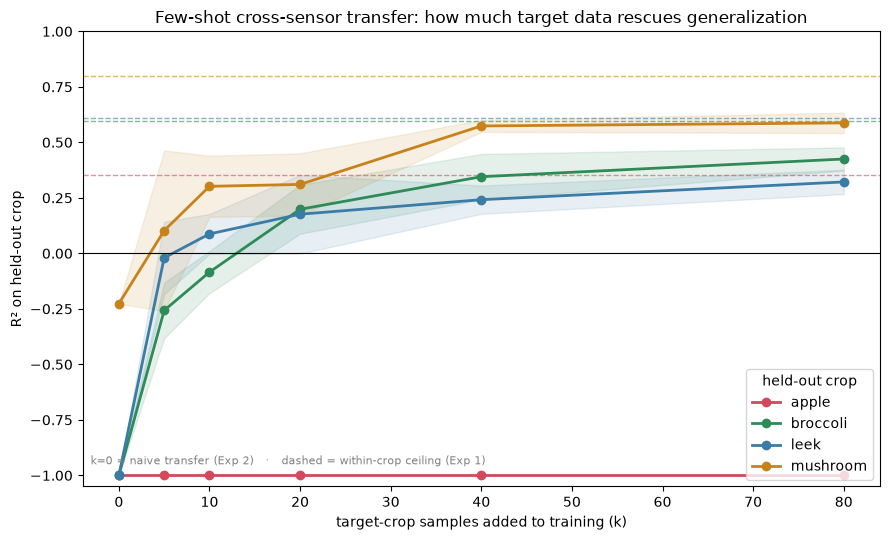

saved plots/fewshot_recovery.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {'apple': '#d1495b', 'broccoli': '#2e8b57', 'leek': '#3a7ca5', 'mushroom': '#c8821a'}

for crop in CROPS:
    sub = fewshot[fewshot['held_out'] == crop].sort_values('k_target_samples')
    ks = sub['k_target_samples'].values
    r2 = sub['R2_mean'].values.clip(min=-1.0)            # clip floor for a readable plot
    ax.plot(ks, r2, 'o-', color=colors[crop], label=f'{crop}', lw=2)
    if 'R2_std' in sub:
        ax.fill_between(ks, (sub['R2_mean']-sub['R2_std']).clip(lower=-1.0),
                        (sub['R2_mean']+sub['R2_std']).clip(lower=-1.0),
                        color=colors[crop], alpha=0.12)
    ax.axhline(ceiling[crop], color=colors[crop], ls='--', lw=1, alpha=0.6)

ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('target-crop samples added to training (k)')
ax.set_ylabel('R² on held-out crop')
ax.set_title('Few-shot cross-sensor transfer: how much target data rescues generalization')
ax.set_ylim(-1.05, 1.0)
ax.legend(title='held-out crop', loc='lower right')
ax.text(0.01, -0.95, 'k=0 = naive transfer (Exp 2)   ·   dashed = within-crop ceiling (Exp 1)',
        transform=ax.get_yaxis_transform(), fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(f'{RESULTS}/plots/fewshot_recovery.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved plots/fewshot_recovery.png')

## 4. Bar chart — naive transfer vs ceiling (the gap)

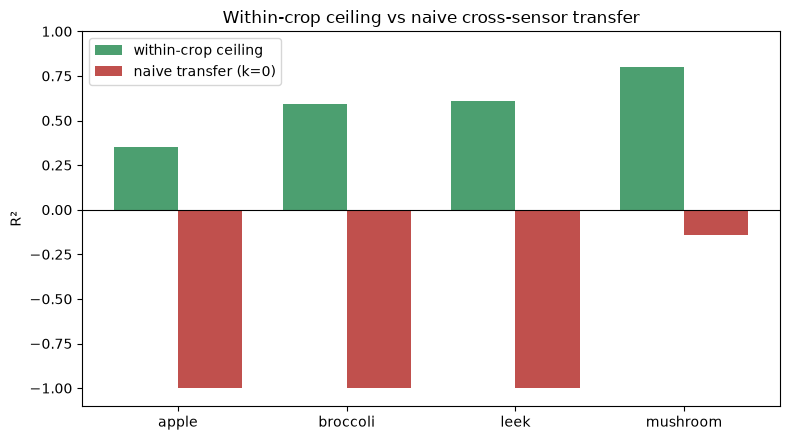

In [15]:
x = np.arange(len(CROPS)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, [ceiling[c] for c in CROPS], w, label='within-crop ceiling', color='#4c9f70')
ax.bar(x + w/2, [max(summary.loc[c, 'naive_R2'], -1) for c in CROPS], w,
       label='naive transfer (k=0)', color='#c0504d')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CROPS)
ax.set_ylabel('R²'); ax.set_ylim(-1.1, 1.0)
ax.set_title('Within-crop ceiling vs naive cross-sensor transfer')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS}/plots/ceiling_vs_naive.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Conclusion

**1. Within-crop (ceiling).** On the shared 141-band space: mushroom 0.80, leek 0.61, broccoli 0.59,
apple 0.34. (Lower than Phase 1's native-band numbers because the common space drops leek's rich
>990 nm bands — the price of a cross-crop feature space.)

**2. Naive transfer fails for every crop.** Training on three crops and testing on the unseen fourth
gives R²<0 and weak correlation (r≈0.2–0.3). A single model does **not** transfer across crops/cameras
out of the box — empirically confirming the generalization gap the dataset was built to expose.

**3. Few-shot adaptation rescues 3 of 4 crops.** Adding only ~5–20 target-crop samples flips
broccoli, leek, and mushroom from negative to positive R², climbing toward their ceilings. Mushroom
recovers fastest/highest (widest, most distinct DM range); **apple never recovers** even at k=80 —
consistent with it being the hardest crop in every prior phase (narrow 13.5–17.4% DM range,
visible-only 430–990 nm spectra, weakest signal).

**Takeaway.** Cross-sensor dry-matter models don't generalize zero-shot, but a small amount of
target-crop calibration data goes a long way — except where the underlying spectral signal is
intrinsically weak (apple). Generalization difficulty tracks signal strength.